# Ensamble de modelos por votación

## Objetivo

En este notebook se construye un modelo de **ensamble por votación** a partir de los tres modelos individuales con mejor desempeño obtenidos en etapas previas del proyecto. La motivación principal es evaluar si la combinación de modelos ya entrenados permite obtener un desempeño más robusto y estable que el de cada estimador por separado.

Los modelos base se cargan desde archivos serializados en formato `.pkl`. A partir de ellos, se implementará un esquema de votación para generar una predicción final conjunta sobre el conjunto de validación o prueba.

---

## Fundamento

Los métodos de ensamble combinan múltiples predictores con el objetivo de aprovechar sus fortalezas individuales y reducir la variabilidad de las predicciones. En particular, los **modelos de votación** constituyen una estrategia simple y efectiva para problemas de clasificación:

- **Hard Voting**: la clase final se determina por mayoría de votos entre los modelos.
- **Soft Voting**: la clase final se obtiene promediando las probabilidades predichas por cada modelo y seleccionando la clase con mayor probabilidad media.

Cuando los modelos base son suficientemente diversos y presentan buenos desempeños individuales, un ensamble puede mejorar la capacidad de generalización del sistema completo.

---

## Estrategia del notebook

El desarrollo se organiza en las siguientes etapas:

1. Carga de librerías y configuración general.
2. Carga del conjunto de datos de prueba.
3. Carga de los tres mejores modelos previamente entrenados.
4. Verificación de compatibilidad entre estimadores.
5. Construcción del ensamble por votación.
6. Evaluación del modelo combinado mediante métricas de clasificación.
7. Comparación del desempeño del ensamble frente a los modelos individuales.

---

## Consideraciones metodológicas

Para que un ensamble por **soft voting** sea aplicable, los modelos base deben contar con el método `predict_proba`. En caso contrario, se optará por un esquema de **hard voting**. 

Además de medir el desempeño global, resulta relevante analizar si el ensamble aporta una mejora consistente en términos de robustez, equilibrio entre métricas y estabilidad de predicción frente a los modelos individuales.


## Importación de librerías y configuración inicial

In [20]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

#modelos de ensamble
from sklearn.ensemble import VotingClassifier

# métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings("ignore")

# ===============================
# CONFIGURACIÓN GENERAL
# ===============================

# Estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Semilla reproducibilidad
RANDOM_STATE = 42

# Paths a modelos
DATA_PATH = "../data/"
MODEL_PATH = "../models/"

# Verificación de paths
print("DATA_PATH:", os.path.exists(DATA_PATH))
print("MODEL_PATH:", os.path.exists(MODEL_PATH))

DATA_PATH: True
MODEL_PATH: True


## Carga de modelos entrenados

In [21]:
# ===============================
# CARGA DE MODELOS ENTRENADOS
# ===============================

model_files = {
    "model_1": "random_forest_tuned.pkl",
    "model_2": "xgboost_tuned.pkl",
    "model_3": "decision_tree_tuned.pkl"
}

models = {}

# Cargar modelos con verificación
for name, file in model_files.items():
    path = os.path.join(MODEL_PATH, file)
    
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f"{name} cargado correctamente desde {file}")
    else:
        print(f"ERROR: No se encontró el archivo {file}")

# Verificación final
print("\nModelos cargados:")
for name in models:
    print(f"- {name}: {type(models[name])}")

model_1 cargado correctamente desde random_forest_tuned.pkl
model_2 cargado correctamente desde xgboost_tuned.pkl
model_3 cargado correctamente desde decision_tree_tuned.pkl

Modelos cargados:
- model_1: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
- model_2: <class 'xgboost.sklearn.XGBClassifier'>
- model_3: <class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [22]:
# ===============================
# VERIFICACIÓN DE COMPATIBILIDAD
# ===============================

compatibility_rows = []

for name, model in models.items():
    has_predict = hasattr(model, "predict")
    has_predict_proba = hasattr(model, "predict_proba")
    has_classes = hasattr(model, "classes_")
    
    model_info = {
        "modelo": name,
        "tipo": type(model).__name__,
        "tiene_predict": has_predict,
        "tiene_predict_proba": has_predict_proba,
        "tiene_classes_": has_classes,
    }
    
    # Intentar recuperar clases aprendidas si existen
    if has_classes:
        try:
            model_info["classes"] = list(model.classes_)
        except Exception:
            model_info["classes"] = "No disponible"
    else:
        model_info["classes"] = "No disponible"
    
    compatibility_rows.append(model_info)

compatibility_df = pd.DataFrame(compatibility_rows)
compatibility_df

,modelo,tipo,tiene_predict,tiene_predict_proba,tiene_classes_,classes
0,model_1,RandomForestClassifier,True,True,True,"[0, 1]"
1,model_2,XGBClassifier,True,True,True,"[0, 1]"
2,model_3,DecisionTreeClassifier,True,True,True,"[0, 1]"


In [23]:
# ===============================
# RESUMEN DE COMPATIBILIDAD
# ===============================

all_have_predict = all(hasattr(model, "predict") for model in models.values())
all_have_predict_proba = all(hasattr(model, "predict_proba") for model in models.values())

print("Resumen de compatibilidad para ensamble:\n")

if all_have_predict:
    print("Todos los modelos implementan 'predict'.")
else:
    print("No todos los modelos implementan 'predict'.")

if all_have_predict_proba:
    print("Todos los modelos implementan 'predict_proba'.")
    print("Es posible utilizar soft voting.")
else:
    print("No todos los modelos implementan 'predict_proba'.")
    print("En principio, conviene utilizar hard voting.")

# Verificación adicional de clases
classes_list = []
for model in models.values():
    if hasattr(model, "classes_"):
        try:
            classes_list.append(tuple(model.classes_))
        except Exception:
            pass

if len(classes_list) > 0 and len(set(classes_list)) == 1:
    print("Todos los modelos parecen haber sido entrenados sobre las mismas clases.")
else:
    print("Revisar que todos los modelos hayan sido entrenados sobre el mismo problema y las mismas clases.")

Resumen de compatibilidad para ensamble:

Todos los modelos implementan 'predict'.
Todos los modelos implementan 'predict_proba'.
Es posible utilizar soft voting.
Todos los modelos parecen haber sido entrenados sobre las mismas clases.


## Implementación del ensamble

En esta sección se implementan dos estrategias de ensamble basadas en votación:

1. **Ensamble con `VotingClassifier`**: los estimadores base se integran en un clasificador de votación estándar de `scikit-learn`, que requiere reentrenar el ensamble sobre el conjunto de entrenamiento.

2. **Ensamble manual**: se combinan directamente las predicciones de los modelos previamente entrenados y cargados desde archivos `.pkl`, sin realizar un nuevo ajuste. Este enfoque resulta especialmente útil cuando se desea reutilizar modelos ya seleccionados y entrenados en etapas anteriores.

Se evaluarán ambas variantes, tanto en esquema de **hard voting** como de **soft voting** cuando sea posible, con el fin de comparar sus resultados y analizar la conveniencia de cada aproximación.

## Construcción del ensamble por votación

A partir de los modelos base previamente cargados, se construyen dos variantes de ensamble mediante `VotingClassifier`:

- **Hard Voting**: la clase final se determina por mayoría de votos.
- **Soft Voting**: la predicción final se obtiene promediando las probabilidades de clase estimadas por cada modelo.


In [24]:
# ===============================
# PREPARACIÓN DE ESTIMADORES
# ===============================

# VotingClassifier espera una lista de tuplas: (nombre, estimador)
estimators = [(name, model) for name, model in models.items()]

print("Estimadores incluidos en el ensamble:")
for name, model in estimators:
    print(f"- {name}: {type(model).__name__}")

Estimadores incluidos en el ensamble:
- model_1: RandomForestClassifier
- model_2: XGBClassifier
- model_3: DecisionTreeClassifier


In [25]:
# ===============================
# CARGA DE DATOS DE ENTRENAMIENTO
# ===============================
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_val = data['X_test']
y_train = data['y_train']
y_val = data['y_test']

In [26]:
# ===============================
# ENSAMBLE POR HARD VOTING
# ===============================

voting_hard = VotingClassifier(
    estimators=estimators,
    voting="hard",
    n_jobs=-1
)

print("VotingClassifier (hard voting) creado correctamente.")
print(voting_hard)
voting_hard.fit(X_train, y_train)


VotingClassifier (hard voting) creado correctamente.
VotingClassifier(estimators=[('model_1',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     max_features='log2',
                                                     min_samples_leaf=19,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('model_2',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8839578671825332,
                                            device=None,
                            

VotingClassifier(estimators=[('model_1',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     max_features='log2',
                                                     min_samples_leaf=19,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('model_2',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8839578671825332,
                                            device=None,
                                            early_stopping_round...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None, min_child_weight=5,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=1,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('model_3',
                              DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=15,
                                                     min_samples_leaf=43,
                                                     min_samples_split=18,
                                                     random_state=42))],
                 n_jobs=-1)

In [27]:
# ===============================
# ENSAMBLE POR SOFT VOTING
# ===============================

if all_have_predict_proba:
    voting_soft = VotingClassifier(
        estimators=estimators,
        voting="soft",
        n_jobs=-1
    )
    print("VotingClassifier (soft voting) creado correctamente.")
    print(voting_soft)
    voting_soft.fit(X_train, y_train)
    print("VotingClassifier con soft voting entrenado correctamente.")
else:
    voting_soft = None
    print("No fue posible crear el ensamble por soft voting.")
    print("Al menos uno de los modelos no implementa 'predict_proba'.")

VotingClassifier (soft voting) creado correctamente.
VotingClassifier(estimators=[('model_1',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     max_features='log2',
                                                     min_samples_leaf=19,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('model_2',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8839578671825332,
                                            device=None,
                            

In [28]:
# ===============================
# ENSAMBLE MANUAL - HARD VOTING
# ===============================

from scipy.stats import mode

# Predicciones individuales de cada modelo
hard_preds_dict = {}
for name, model in models.items():
    hard_preds_dict[name] = model.predict(X_val)

# Matriz de predicciones: shape -> (n_modelos, n_muestras)
hard_preds_matrix = np.vstack(list(hard_preds_dict.values()))

# Votación mayoritaria por columna
manual_hard_pred = mode(hard_preds_matrix, axis=0, keepdims=False).mode

print("Ensamble manual por hard voting generado correctamente.")
print(f"Shape de predicción final: {manual_hard_pred.shape}")

Ensamble manual por hard voting generado correctamente.
Shape de predicción final: (1022,)


In [29]:
# ===============================
# ENSAMBLE MANUAL - SOFT VOTING
# ===============================

if all_have_predict_proba:
    # Probabilidades de clase positiva de cada modelo
    soft_probas_dict = {}
    for name, model in models.items():
        soft_probas_dict[name] = model.predict_proba(X_val)[:, 1]

    # Matriz de probabilidades: shape -> (n_modelos, n_muestras)
    soft_probas_matrix = np.vstack(list(soft_probas_dict.values()))

    # Promedio de probabilidades
    manual_soft_proba = soft_probas_matrix.mean(axis=0)

    # Umbral clásico 0.5
    manual_soft_pred = (manual_soft_proba >= 0.5).astype(int)

    print("Ensamble manual por soft voting generado correctamente.")
    print(f"Shape de probabilidad final: {manual_soft_proba.shape}")
    print(f"Shape de predicción final: {manual_soft_pred.shape}")
else:
    manual_soft_proba = None
    manual_soft_pred = None
    print("No fue posible generar soft voting manual porque no todos los modelos implementan predict_proba().")

Ensamble manual por soft voting generado correctamente.
Shape de probabilidad final: (1022,)
Shape de predicción final: (1022,)


In [30]:
# ===============================
# FUNCIÓN AUXILIAR DE EVALUACIÓN
# ===============================

def evaluate_classifier(y_true, y_pred, y_proba=None, model_name="Modelo"):
    """
    Evalúa un clasificador en términos de métricas principales.
    Si se proveen probabilidades, también calcula ROC AUC.
    """
    results = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "f3_score": fbeta_score(y_true, y_pred, beta=3, zero_division=0),
    }
    
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        results["roc_auc"] = np.nan
    
    return results

In [31]:
# ===============================
# EVALUACIÓN DE VOTINGCLASSIFIER
# ===============================

results_voting = []

# Hard voting
y_pred_vh = voting_hard.predict(X_val)
results_voting.append(
    evaluate_classifier(
        y_true=y_val,
        y_pred=y_pred_vh,
        y_proba=None,
        model_name="VotingClassifier - Hard"
    )
)

# Soft voting
if voting_soft is not None:
    y_pred_vs = voting_soft.predict(X_val)
    y_proba_vs = voting_soft.predict_proba(X_val)[:, 1]

    results_voting.append(
        evaluate_classifier(
            y_true=y_val,
            y_pred=y_pred_vs,
            y_proba=y_proba_vs,
            model_name="VotingClassifier - Soft"
        )
    )

results_voting_df = pd.DataFrame(results_voting)
results_voting_df

,modelo,accuracy,precision,recall,f1_score,f2_score,f3_score,roc_auc
0,VotingClassifier - Hard,0.780822,0.149194,0.74,0.248322,0.412946,0.530086,NaN
1,VotingClassifier - Soft,0.772016,0.132530,0.66,0.220736,0.367483,0.472103,0.823169


In [32]:
# ===============================
# EVALUACIÓN DE ENSAMBLES MANUALES
# ===============================

results_manual = []

# Hard voting manual
results_manual.append(
    evaluate_classifier(
        y_true=y_val,
        y_pred=manual_hard_pred,
        y_proba=None,
        model_name="Manual Voting - Hard"
    )
)

# Soft voting manual
if manual_soft_pred is not None and manual_soft_proba is not None:
    results_manual.append(
        evaluate_classifier(
            y_true=y_val,
            y_pred=manual_soft_pred,
            y_proba=manual_soft_proba,
            model_name="Manual Voting - Soft"
        )
    )

results_manual_df = pd.DataFrame(results_manual)
results_manual_df

,modelo,accuracy,precision,recall,f1_score,f2_score,f3_score,roc_auc
0,Manual Voting - Hard,0.780822,0.149194,0.74,0.248322,0.412946,0.530086,NaN
1,Manual Voting - Soft,0.772016,0.132530,0.66,0.220736,0.367483,0.472103,0.823169


In [33]:
# ===============================
# COMPARACIÓN FINAL DE ENSAMBLES
# ===============================

ensemble_results_df = pd.concat(
    [results_voting_df, results_manual_df],
    axis=0,
    ignore_index=True
)

ensemble_results_df = ensemble_results_df.sort_values(
    by="f3_score",
    ascending=False
).reset_index(drop=True)

ensemble_results_df

,modelo,accuracy,precision,recall,f1_score,f2_score,f3_score,roc_auc
0,VotingClassifier - Hard,0.780822,0.149194,0.74,0.248322,0.412946,0.530086,NaN
1,Manual Voting - Hard,0.780822,0.149194,0.74,0.248322,0.412946,0.530086,NaN
2,VotingClassifier - Soft,0.772016,0.132530,0.66,0.220736,0.367483,0.472103,0.823169
3,Manual Voting - Soft,0.772016,0.132530,0.66,0.220736,0.367483,0.472103,0.823169


In [34]:
# ===============================
# FUNCIÓN PARA MATRIZ DE CONFUSIÓN
# ===============================

def plot_confusion_and_report(y_true, y_pred, title="Matriz de confusión"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()
    
    print("Reporte de clasificación:\n")
    print(classification_report(y_true, y_pred, digits=4))

Mejor ensamble según F3-score: VotingClassifier - Hard


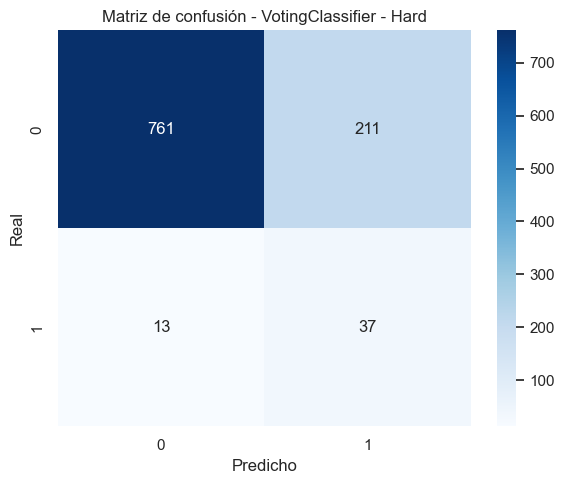

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.9832    0.7829    0.8717       972
           1     0.1492    0.7400    0.2483        50

    accuracy                         0.7808      1022
   macro avg     0.5662    0.7615    0.5600      1022
weighted avg     0.9424    0.7808    0.8412      1022



In [35]:
# ===============================
# VISUALIZACIÓN DEL MEJOR ENSAMBLE
# ===============================

best_ensemble_name = ensemble_results_df.loc[0, "modelo"]
print(f"Mejor ensamble según F3-score: {best_ensemble_name}")

if best_ensemble_name == "VotingClassifier - Hard":
    best_pred = y_pred_vh
elif best_ensemble_name == "VotingClassifier - Soft":
    best_pred = y_pred_vs
elif best_ensemble_name == "Manual Voting - Hard":
    best_pred = manual_hard_pred
elif best_ensemble_name == "Manual Voting - Soft":
    best_pred = manual_soft_pred
else:
    raise ValueError("No se pudo identificar el mejor ensamble.")

plot_confusion_and_report(
    y_true=y_val,
    y_pred=best_pred,
    title=f"Matriz de confusión - {best_ensemble_name}"
)

## Comparación entre modelos base y mejor ensamble

Finalmente, se compara el desempeño original de los modelos base seleccionados con el mejor resultado obtenido mediante ensamble. 

Este análisis permite determinar si la estrategia de votación aporta una mejora efectiva respecto de los clasificadores individuales, especialmente en las métricas más relevantes para el problema.

In [36]:
# ===============================
# RESULTADOS DE LOS MODELOS BASE
# ===============================

base_results = []

for name, model in models.items():
    
    # Predicciones
    y_pred = model.predict(X_val)
    
    # Probabilidades (si existen)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = None

    # Evaluación
    result = evaluate_classifier(
        y_true=y_val,
        y_pred=y_pred,
        y_proba=y_proba,
        model_name=name
    )
    
    base_results.append(result)

# DataFrame final
base_results_df = pd.DataFrame(base_results)

# Ordenado por métrica principal
base_results_df = base_results_df.sort_values(
    by="recall",
    ascending=False
).reset_index(drop=True)

base_results_df

,modelo,accuracy,precision,recall,f1_score,f2_score,f3_score,roc_auc
0,model_1,0.775930,0.149020,0.76,0.249180,0.417582,0.539007,0.828477
1,model_3,0.772994,0.138889,0.70,0.231788,0.387168,0.498575,0.797716
2,model_2,0.777886,0.132780,0.64,0.219931,0.362812,0.463097,0.810905


In [37]:
# ===============================
# COMPARACIÓN: MODELOS BASE VS MEJOR ENSAMBLE
# ===============================

# Seleccionar el mejor ensamble según la métrica prioritaria
metric_sort = "recall"  # ajustar si querés priorizar otra métrica
best_ensemble_row = ensemble_results_df.sort_values(by=metric_sort, ascending=False).iloc[[0]]

# Unir resultados base + mejor ensamble
comparison_df = pd.concat(
    [base_results_df.copy(), best_ensemble_row.copy()],
    axis=0,
    ignore_index=True
)

# Ordenar por la métrica principal
comparison_df = comparison_df.sort_values(by=metric_sort, ascending=False).reset_index(drop=True)

# Mostrar tabla comparativa
comparison_df.style.highlight_max(subset=["recall"], color="blue")

,modelo,accuracy,precision,recall,f1_score,f2_score,f3_score,roc_auc
0,model_1,0.775930,0.149020,0.760000,0.249180,0.417582,0.539007,0.828477
1,VotingClassifier - Hard,0.780822,0.149194,0.740000,0.248322,0.412946,0.530086,nan
2,model_3,0.772994,0.138889,0.700000,0.231788,0.387168,0.498575,0.797716
3,model_2,0.777886,0.132780,0.640000,0.219931,0.362812,0.463097,0.810905


In [38]:
# ===============================
# CONCLUSIÓN AUTOMÁTICA
# ===============================

best_model_name = comparison_df.loc[0, "modelo"]
best_model_f4 = comparison_df.loc[0, "recall"]

print(f"Mejor modelo según recall: {best_model_name}")
print(f"recall: {best_model_f4:.4f}")

if "Voting" in best_model_name:
    print("El ensamble supera a los modelos individuales.")
else:
    print("Un modelo individual sigue siendo el mejor.")

Mejor modelo según recall: model_1
recall: 0.7600
Un modelo individual sigue siendo el mejor.


# Conclusión